# Análisis para múltiples áreas urbanas

Para demostrar la facilidad con la que la librería permite realizar el mismo
análisis en distintos contextos, se crea una función `basic_analysis` que, dada
un área urbana, calcula índices de accesibilidad a farmacias (extraídas de OSM)
usando la función de índice E2SFCA. Esta función se aplica a cuatro áreas
urbanas de Chile, pudiendo comparar los resultados obtenidos de manera
sencilla.

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import datetime
from pathlib import Path

import geopandas as gpd

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors

import xmin
from xmin.dataset import extract_osm_subset
from xmin.indices import EnhancedTwoStepFca

In [3]:
RAW_DATA_PATH = Path("../../data/raw")  # datos no procesados
PRE_DATA_PATH = Path("../../data/processed")  # datos preprocesados
IMG_PATH = Path("../../reports/figures")
xmin.config.quackosm_working_directory = Path("../../data/interim/quackosm")

OSM_CHILE_PATH = RAW_DATA_PATH / "osm" / "Chile.osm.pbf"
CENSO_PATH = PRE_DATA_PATH / "censo" / "Cartografia.gpkg"
AMENITY_VERDES_PATH = PRE_DATA_PATH / "amenities" / "areas_verdes.gpkg"

## Definición de análisis

In [4]:
def basic_analysis(
    regions: gpd.GeoDataFrame, region_name: str
) -> xmin.AccessibilityRatings:
    """
    Ejecuta un análisis básico para la región entregada.
    """

    regions_hull = regions.union_all().convex_hull
    osm_path = PRE_DATA_PATH / "osm" / f"{region_name}.osm.pbf"
    if not osm_path.exists():
        print("Extrayendo PBF...")
        extract_osm_subset(OSM_CHILE_PATH, osm_path, bounds=regions_hull)

    # generate origins
    print("Generando orígenes...")
    manzanas = gpd.read_file(
        CENSO_PATH,
        layer="Manzanas_CPV24",
        mask=regions.union_all(),
        use_arrow=True,
    ).rename(columns={"n_per": "population"})
    origins = xmin.Origins.create_grid(
        regions=regions, h3_resolution=10, population_gdf=manzanas
    )

    # generate amenities
    print("Generando destinos...")
    farmacias = xmin.Amenity.from_osm(
        name="farmacias",
        osm_path=osm_path,
        osm_filter={"amenity": ["pharmacy"]},
    )

    # calculate ttms
    ttms = xmin.TravelTimeMatrices.compute(
        origins=origins,
        amenities=[farmacias],
        gtfs_paths=[],
        osm_path=osm_path,
        snap_to_network=False,
        max_time=datetime.timedelta(minutes=30),
        transport_modes=["WALK"],
        chunk_size=50,
    )

    # calculate accessibility ratings
    return xmin.AccessibilityRatings.compute(
        ttms,
        index_function=EnhancedTwoStepFca(
            catchment_areas=[
                (0, 10, 1.00),
                (10, 20, 0.42),
                (20, 30, 0.03),
            ],
            desired_ratio=3_000,
        ),
    )

## Generación de resultados

Para obtener los resultados de un área urbana en particular, es tan sencillo
como obtener sus límites y ejecutar `basic_analysis`.

In [5]:
limites_urbanos_full = gpd.read_file(
    CENSO_PATH,
    layer="Limite_Urbano_CPV24",
)

limites_stgo = limites_urbanos_full[
    (limites_urbanos_full["LOCALIDAD"] == "GRAN SANTIAGO")
]
limites_valpo = limites_urbanos_full[
    (limites_urbanos_full["LOCALIDAD"] == "GRAN VALPARAÍSO")
]
limites_conce = limites_urbanos_full[
    (limites_urbanos_full["LOCALIDAD"] == "GRAN CONCEPCIÓN")
]
limites_pm = limites_urbanos_full[
    (limites_urbanos_full["COMUNA"] == "PUERTO MONTT")
]

In [6]:
acc_stgo = basic_analysis(limites_stgo, "Santiago")

Generando orígenes...
Generando destinos...


Calculando tiempos de viaje desde cada origen...


  0%|          | 0/63199 [00:00<?, ?it/s]

Calculando índices para cada necesidad...


  0%|          | 0/1 [00:00<?, ?it/s]

In [7]:
acc_valpo = basic_analysis(limites_valpo, "Valparaiso")

Generando orígenes...
Generando destinos...


Calculando tiempos de viaje desde cada origen...


  0%|          | 0/12570 [00:00<?, ?it/s]

Calculando índices para cada necesidad...


  0%|          | 0/1 [00:00<?, ?it/s]

In [8]:
acc_conce = basic_analysis(limites_conce, "Concepcion")

Generando orígenes...
Generando destinos...


Calculando tiempos de viaje desde cada origen...


  0%|          | 0/13607 [00:00<?, ?it/s]

Calculando índices para cada necesidad...


  0%|          | 0/1 [00:00<?, ?it/s]

In [9]:
acc_pm = basic_analysis(limites_pm, "Puerto_Montt")

Generando orígenes...
Generando destinos...


Calculando tiempos de viaje desde cada origen...


  0%|          | 0/3863 [00:00<?, ?it/s]

Calculando índices para cada necesidad...


  0%|          | 0/1 [00:00<?, ?it/s]

## Visualización

Obteniendo los objetos `AccessibilityRatings` para cada área urbana, los
resultados se pueden visualizar y comparar directamente.

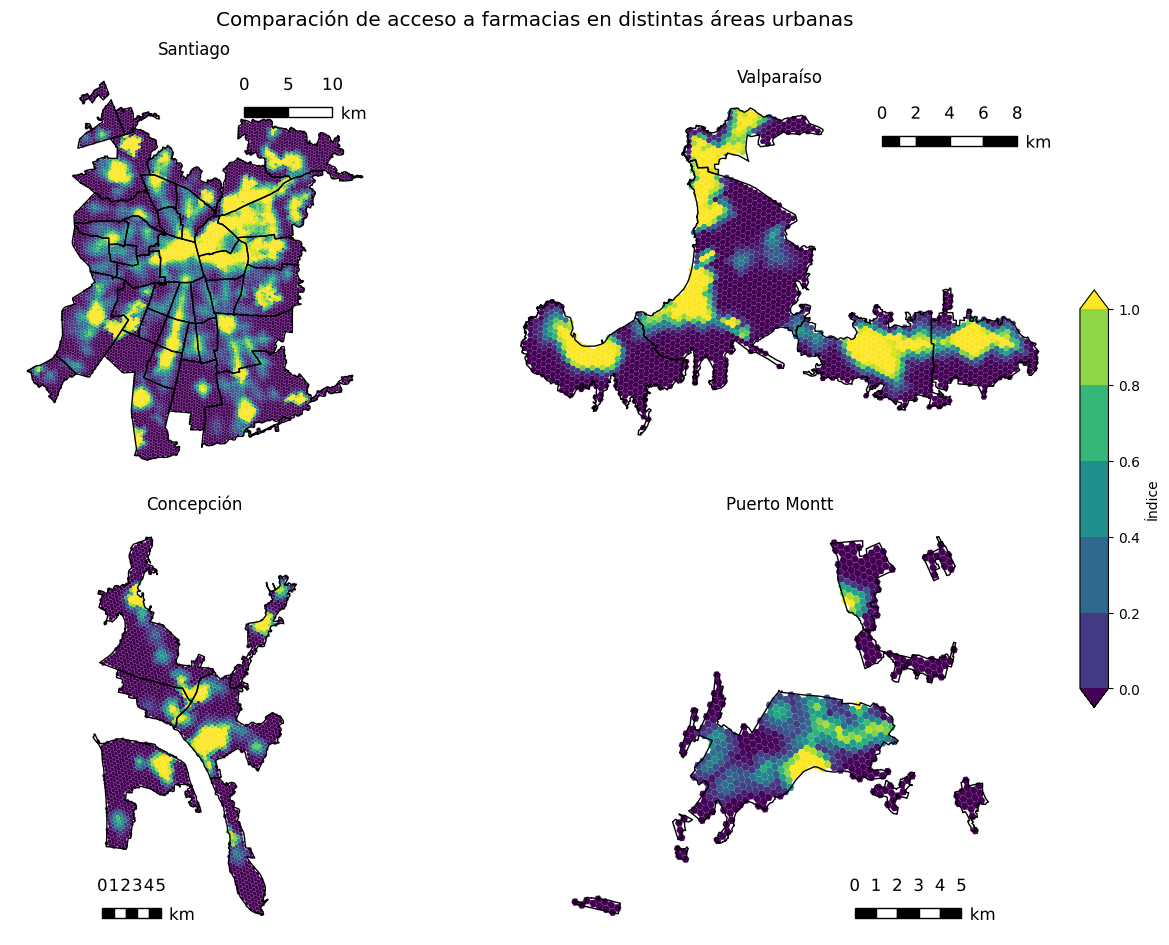

In [12]:
fig = plt.figure(figsize=(2 * 6.4, 2 * 4.8))
gs = GridSpec(4, 3, figure=fig, width_ratios=[100, 100, 5])
ax_stgo = fig.add_subplot(gs[0:2, 0])
ax_valpo = fig.add_subplot(gs[0:2, 1])
ax_conce = fig.add_subplot(gs[2:4, 0])
ax_pm = fig.add_subplot(gs[2:4, 1])
ax_cb = fig.add_subplot(gs[1:3, 2])

norm = mcolors.BoundaryNorm(
    [1e-10, 0.2, 0.4, 0.6, 0.8, 1.0], ncolors=256, extend="both"
)

for ax, acc, name, scalebar_pos in zip(
    (ax_stgo, ax_valpo, ax_conce, ax_pm),
    (acc_stgo, acc_valpo, acc_conce, acc_pm),
    ("Santiago", "Valparaíso", "Concepción", "Puerto Montt"),
    ("upper right", "upper right", "lower left", "lower right"),
):
    # aggregate to level 9 and visualize
    acc.aggregate(9).visualize.choropleth(
        "total",
        ax=ax,
        overlay_cfg=xmin.OverlayConfig(
            show_scalebar=True, scalebar_kwds={"location": scalebar_pos}
        ),
    )
    ax.set_axis_off()
    ax.set_title(name)

cbar = plt.cm.ScalarMappable(norm=norm, cmap="viridis")
axCbar = fig.colorbar(cbar, cax=ax_cb)
axCbar.set_label(f"Índice")

fig.suptitle(
    "Comparación de acceso a farmacias en distintas áreas urbanas",
    fontsize="x-large",
)

plt.tight_layout()
plt.savefig(IMG_PATH / "multiple_city_comparison.pdf")